        Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1/31/1980  1980   Jan          1               108.24                0.50   
1  2/29/1980  1980   Feb          1                98.75                0.75   
2  3/31/1980  1980   Mar          1               107.48                0.20   
3  4/30/1980  1980   Apr          1               115.01                1.00   
4  5/31/1980  1980   May          1                98.72                0.20   

       Price  Advertising_Expenditure  Competition     GDP  Growth_Rate  \
0  27483.571                     1558            7  60.223     0.010000   
1  24308.678                     3048            4  45.986    -0.309594   
2  28238.443                     3137            3  35.141    -0.308614   
3  32615.149                     1653            7  45.673     0.230596   
4  23829.233                     1319            4  52.997     0.138197   

   unemployment_rate  Automobile_Sales     Vehicle_Type        City 

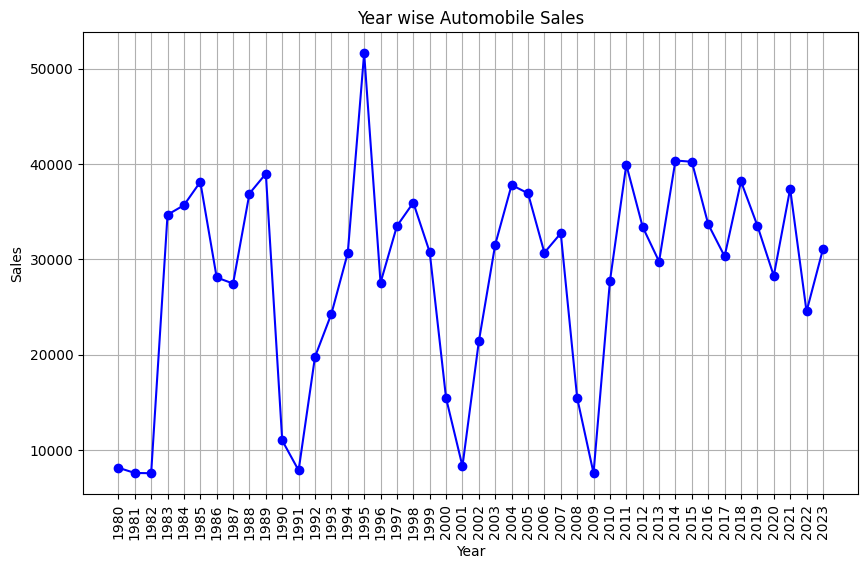

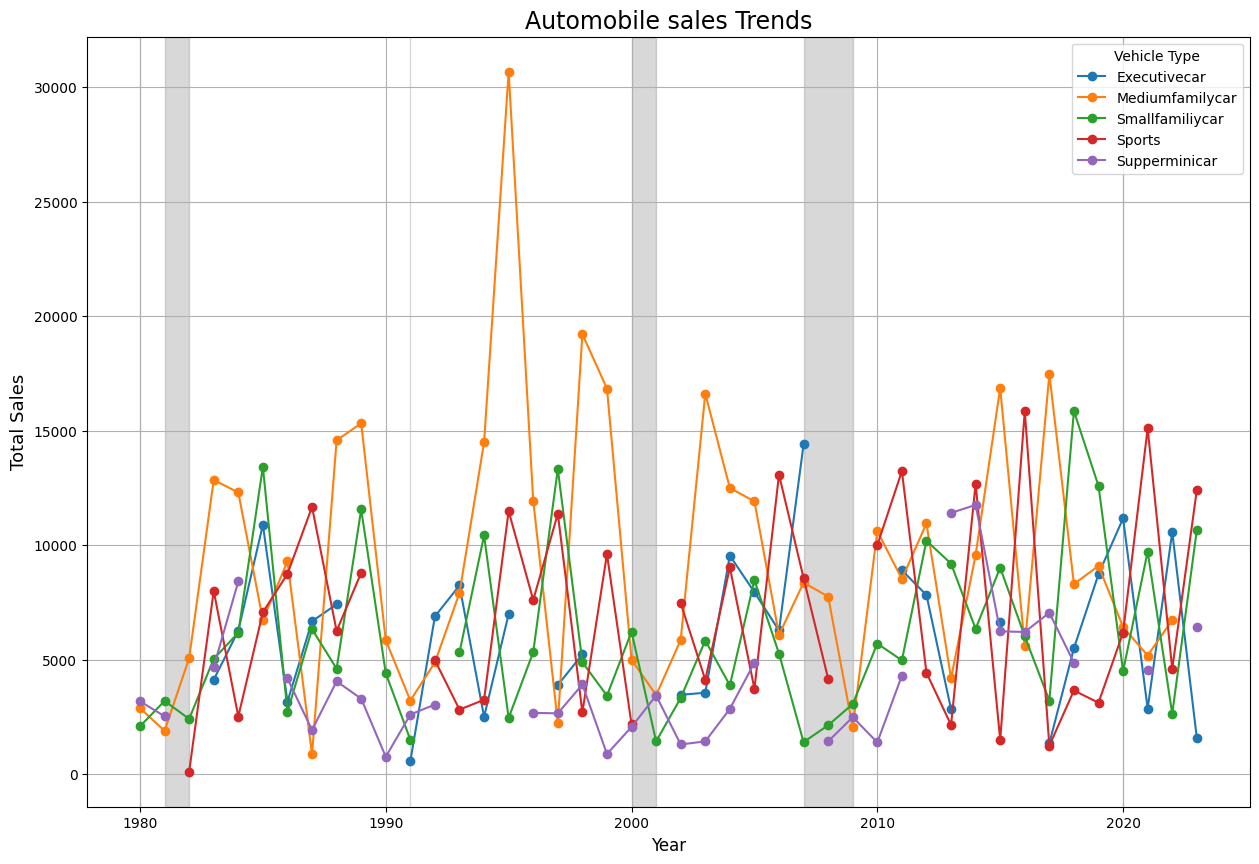

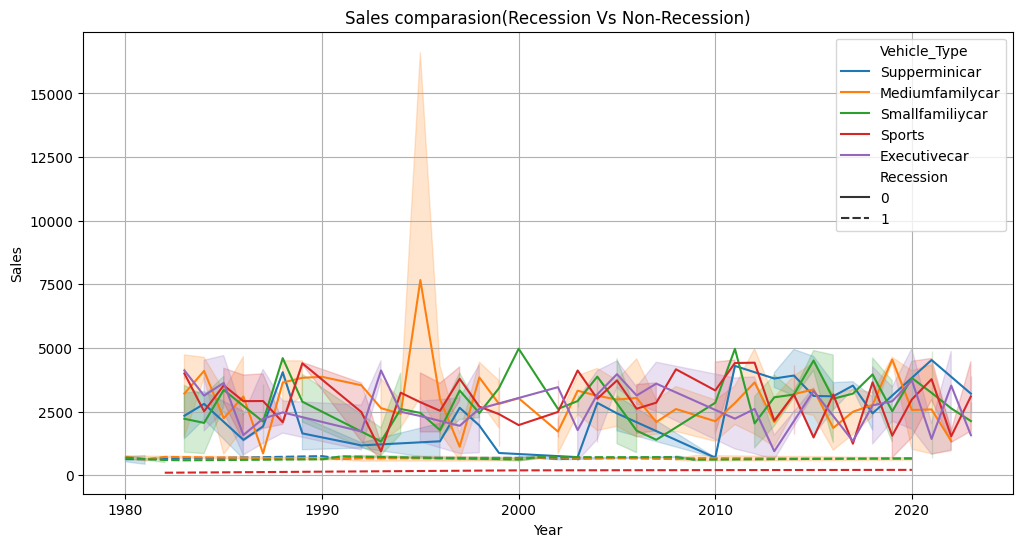

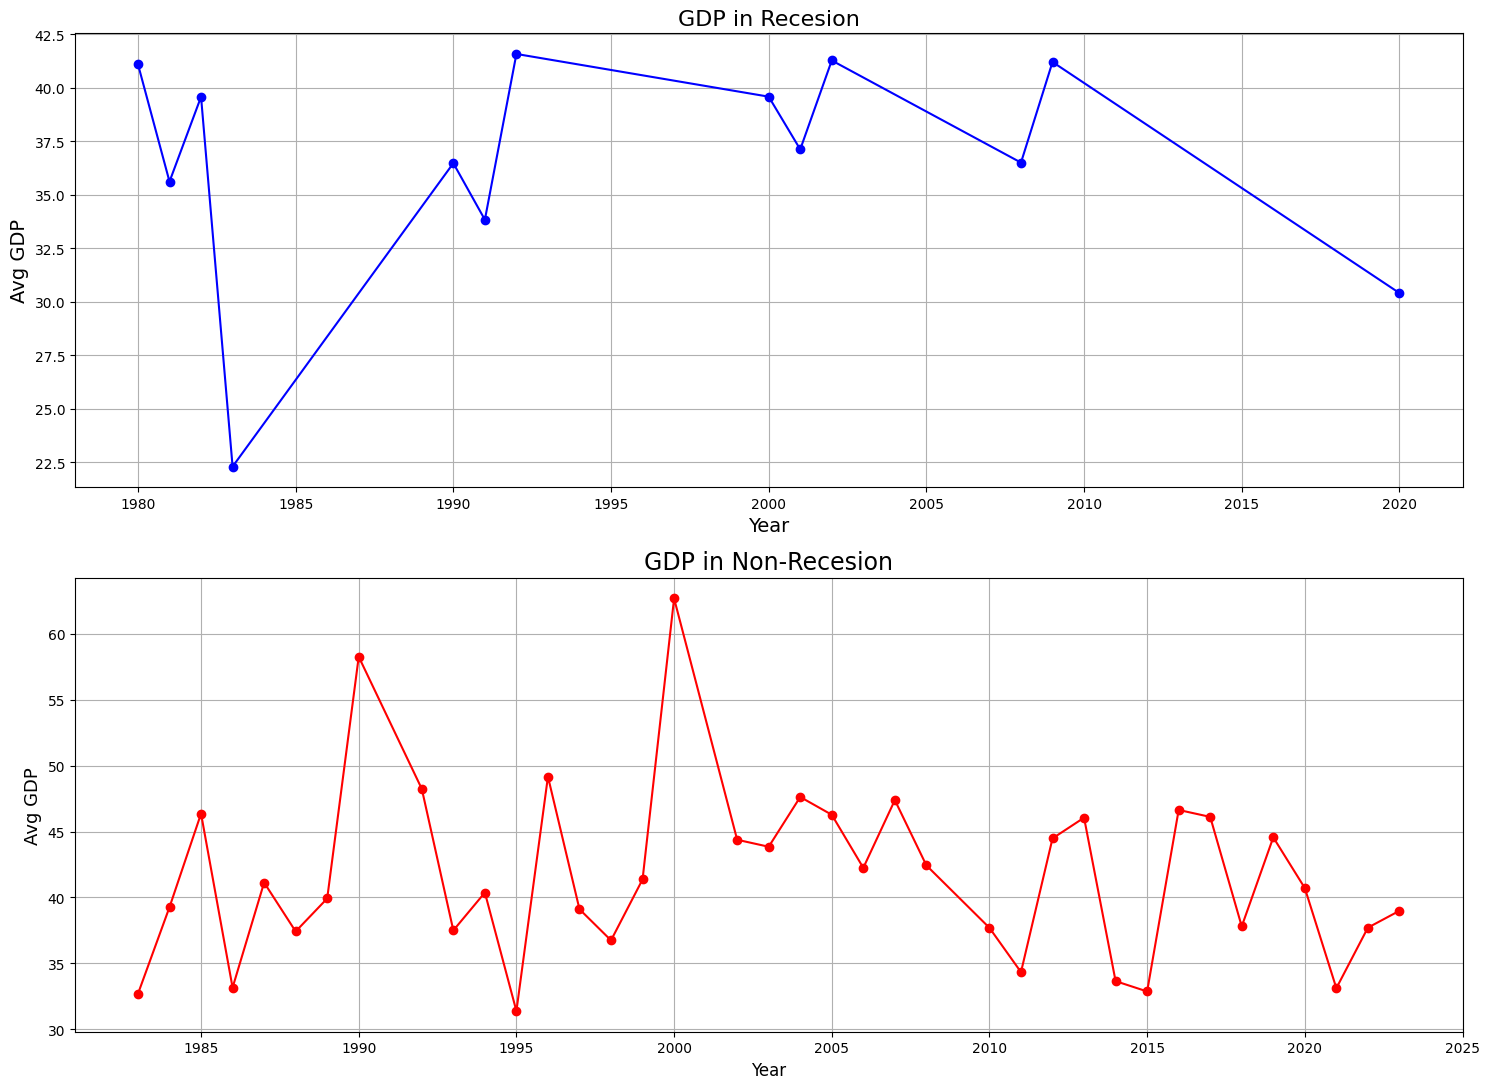

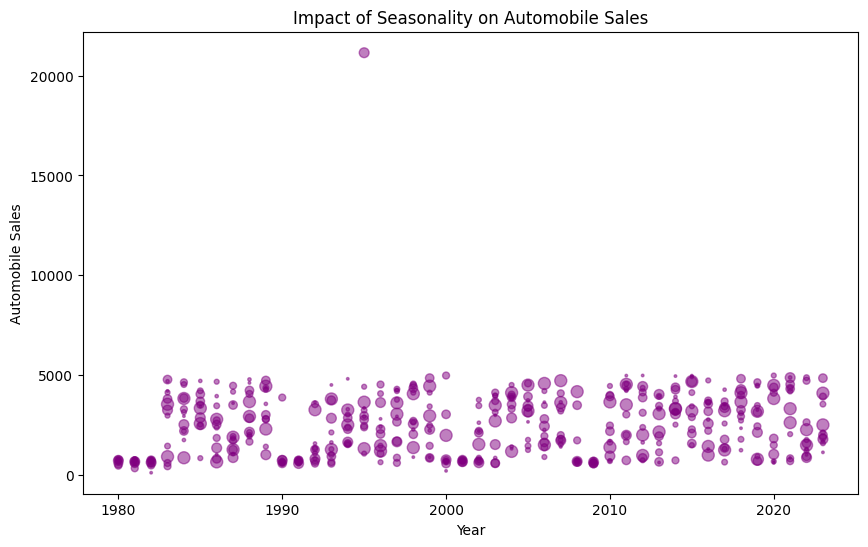

   Year         Price  Automobile_Sales
0  1980  26479.776500            8147.4
1  1981  22043.840583            7600.9
2  1982  24033.323583            7573.8
3  1991  24429.537583            7870.7
4  2000  24844.927917           15441.5
5  2001  24031.917417            8305.6
6  2007  25124.682000           32726.0
7  2008  22819.698917           15474.6
8  2009  24882.859833            7580.3
9  2020  24019.827833           28262.0


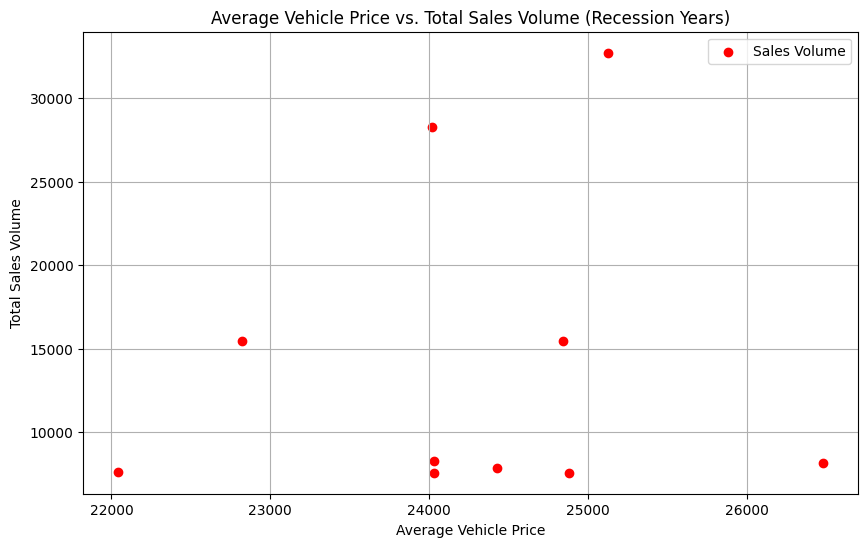

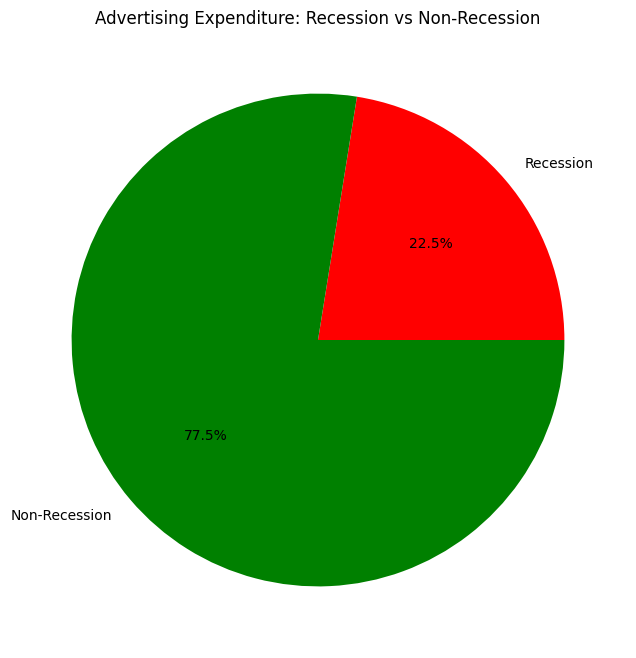

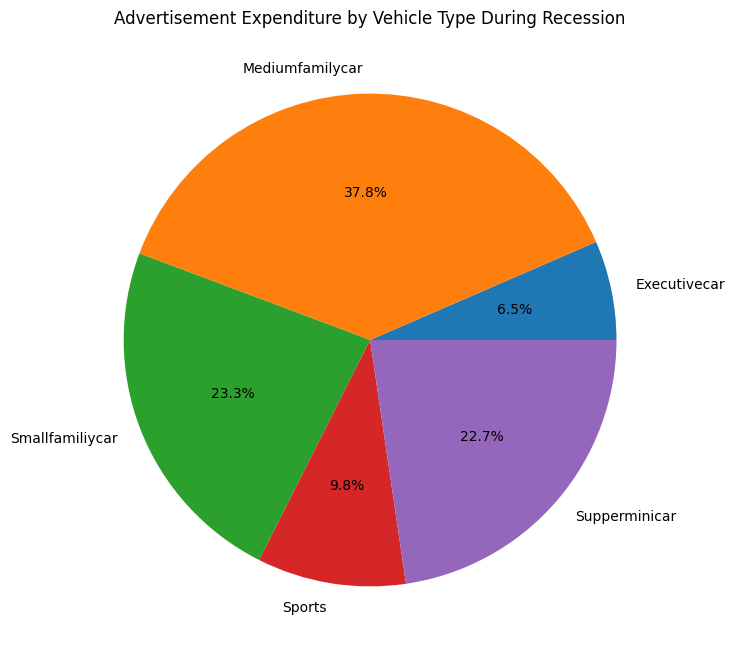

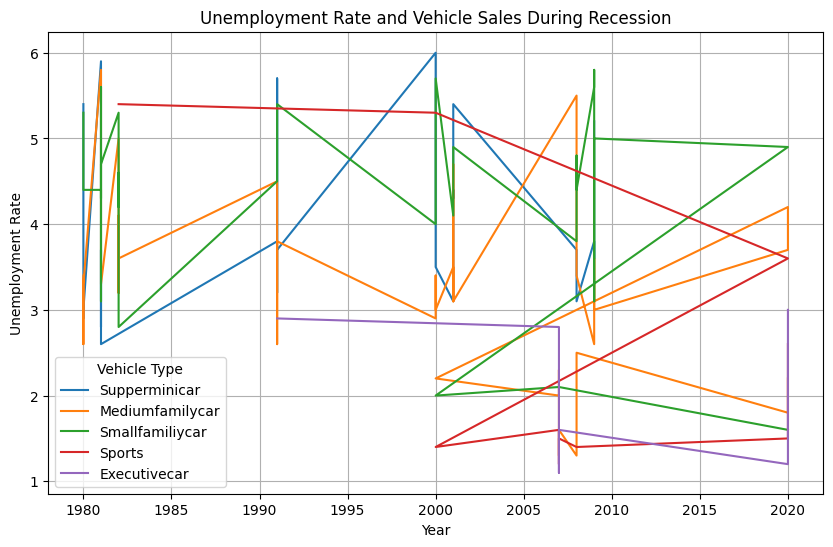

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

#1.1
dfs = pd.read_csv('/content/historical_automobile_sales.csv')
print(dfs.head())

sales_by_year = dfs.groupby('Year')['Automobile_Sales'].sum()

plt.figure(figsize = (10,6))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', color='b')
plt.title('Year wise Automobile Sales')
plt.xticks(sales_by_year.index,rotation = 90)
plt.xlabel('Year')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

#1.2
#The data is filtered to concentrate on recession periods
rec_periods = dfs[dfs['Recession'] == 1]

#Vehicle type and year data are grouped here, then sum it.
vehicle_types = dfs.groupby(['Year', 'Vehicle_Type'])['Automobile_Sales'].sum().unstack()

# Create a line plot for each vehicle type
plt.figure(figsize=(15,10))

# Vehicle type is plotted with different lines
for vehicle_type in vehicle_types.columns:
    plt.plot(vehicle_types.index, vehicle_types[vehicle_type], marker='o', label=vehicle_type)
rec_years = [(1980, 1980), (1981, 1982), (1991, 1991), (2000, 2001), (2007, 2009), (2020, 2020)]
for start, end in rec_years:
    plt.axvspan(start, end, color='gray', alpha=0.3)

# labeling the plot
plt.title('Automobile sales Trends', fontsize=17)
plt.ylabel('Total Sales', fontsize=13)
plt.xlabel('Year', fontsize=12)
plt.grid(True)
plt.legend(title='Vehicle Type')
#ploting the lines
plt.show()

#1.3

import seaborn as sns
# Plot using seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=dfs, x='Year', y='Automobile_Sales', hue='Vehicle_Type', style='Recession')
plt.title('Sales comparasion(Recession Vs Non-Recession)')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

#1.4
import matplotlib.pyplot as plt
rec_gdp = dfs[dfs['Recession'] == 1].groupby('Year')['GDP'].mean()
non_rec_gdp = dfs[dfs['Recession'] == 0].groupby('Year')['GDP'].mean()
fig, axes = plt.subplots(2, 1, figsize=(15, 11))
axes[0].plot(rec_gdp.index, rec_gdp, marker='o', color='blue')
axes[0].set_title('GDP in Recesion', fontsize=16)
axes[0].set_xlabel('Year', fontsize=14)
axes[0].set_ylabel('Avg GDP', fontsize=14)
axes[0].grid(True)
axes[1].plot(non_rec_gdp.index, non_rec_gdp, marker='o', color='red')
axes[1].set_title('GDP in Non-Recesion', fontsize=17)
axes[1].set_ylabel('Avg GDP', fontsize=13)
axes[1].set_xlabel('Year', fontsize=12)

axes[1].grid(True)
plt.tight_layout()
plt.show()



#1.5

plt.figure(figsize=(10, 6))
plt.scatter(dfs['Year'], dfs['Automobile_Sales'], s=dfs['Seasonality_Weight']*50, alpha=0.5, color='purple')
plt.title('Impact of Seasonality on Automobile Sales')
plt.xlabel('Year')
plt.ylabel('Automobile Sales')
plt.show()


#1.6
# Group recession data by Year and calculate mean Price and total Automobile Sales
recession_grouped = recession_data.groupby('Year').agg({
    'Price': 'mean',
    'Automobile_Sales': 'sum'
}).reset_index()

print(recession_grouped)
plt.figure(figsize=(10,6))
plt.scatter(recession_grouped['Price'], recession_grouped['Automobile_Sales'], color='r', label='Sales Volume')
plt.title('Average Vehicle Price vs. Total Sales Volume (Recession Years)')
plt.xlabel('Average Vehicle Price')
plt.ylabel('Total Sales Volume')
plt.grid(True)
plt.legend()
plt.show()


#1.7

# Calculate total advertising expenditure for recession vs non-recession
ad_exp_recession = recession_data['Advertising_Expenditure'].sum()
ad_exp_non_recession = non_recession_data['Advertising_Expenditure'].sum()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie([ad_exp_recession, ad_exp_non_recession], labels=['Recession', 'Non-Recession'], autopct='%1.1f%%', colors=['red', 'green'])
plt.title('Advertising Expenditure: Recession vs Non-Recession')
plt.show()


#1.8
ad_exp_by_vehicle = recession_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(ad_exp_by_vehicle, labels=ad_exp_by_vehicle.index, autopct='%1.1f%%')
plt.title('Advertisement Expenditure by Vehicle Type During Recession')
plt.show()

#1.9

# Line plot for unemployment rate and sales for each vehicle type during recession
plt.figure(figsize=(10, 6))
for vehicle_type in recession_data['Vehicle_Type'].unique():
    vehicle_data = recession_data[recession_data['Vehicle_Type'] == vehicle_type]
    plt.plot(vehicle_data['Year'], vehicle_data['unemployment_rate'], label=vehicle_type)

plt.title('Unemployment Rate and Vehicle Sales During Recession')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate')
plt.legend(title='Vehicle Type')
plt.grid(True)
plt.show()

